# Flexibility Policy Baseline

Paired experiment: start greedy and adaptive-flexibility search from the exact same random K43 colorings. The adaptive policy follows exact greedy while its monitored flexibility reserve is healthy, then permits bounded temporary damage and selects the action producing the greatest future flexibility.

In [2]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ramsey.RActionFlexibility import (
    RActionFlexibilityLandscape,
    calculate_action_flexibility_landscape,
)

from ramsey.RFlexibility import (
    DEFAULT_FLEXIBILITY_BUDGETS,
    RFlexibilityProfile,
    calculate_flexibility,
)

from ramsey.RFlexibilityPolicy import (
    RFlexibilityPolicy,
    RFlexibilityPolicyConfig,
    RFlexibilityPolicyDecision,
    select_flexibility_action,
)

RANDOM_SEED = 202_608_072
NUMBER_OF_RUNS = 3
STEPS_PER_RUN = 128
REPORT_INTERVAL = 16

FLEXIBILITY_BUDGETS = (0, 1, 2, 5, 10, 20)
MONITOR_BUDGET = 5
FLEXIBILITY_FLOOR = 0.55
MAXIMUM_TEMPORARY_DAMAGE = 5

rng = np.random.default_rng(RANDOM_SEED)
graph = RGraph(RProblem.r55(n_vertices=43))

seed_colorings = [
    RColoring(
        graph,
        rng.integers(0, 2, size=graph.number_of_edges, dtype=np.uint8),
    )
    for _ in range(NUMBER_OF_RUNS)
]

flex_config = RFlexibilityPolicyConfig(
    budgets=FLEXIBILITY_BUDGETS,
    monitor_budget=MONITOR_BUDGET,
    flexibility_floor=FLEXIBILITY_FLOOR,
    maximum_temporary_damage=MAXIMUM_TEMPORARY_DAMAGE,
)

print('Runs:', NUMBER_OF_RUNS)
print('Steps per run:', STEPS_PER_RUN)
print('Flexibility floor:', FLEXIBILITY_FLOOR)
print('Monitor: F(', MONITOR_BUDGET, ')', sep='')
print('Maximum temporary damage:', MAXIMUM_TEMPORARY_DAMAGE)


Runs: 3
Steps per run: 128
Flexibility floor: 0.55
Monitor: F(5)
Maximum temporary damage: 5


In [3]:
def make_environment(seed_coloring):
    environment = REnvironment(
        graph=graph,
        objective=RMonochromaticObjective(),
        memory=RNullMemory(),
        config=REnvironmentConfig(max_steps=STEPS_PER_RUN),
    )
    environment.reset(seed_coloring)
    return environment


def current_flexibility(environment):
    analysis = environment.analyze_actions()
    return calculate_flexibility(
        analysis.action_analysis.immediate_rewards,
        FLEXIBILITY_BUDGETS,
    )


def run_one(seed_coloring, *, mode, run_rng):
    environment = make_environment(seed_coloring)
    initial_score = environment.state.score
    trajectory = []
    reorganization_steps = 0
    start = perf_counter()

    while not (environment.terminated or environment.truncated):
        analysis = environment.analyze_actions()
        flexibility = calculate_flexibility(
            analysis.action_analysis.immediate_rewards,
            FLEXIBILITY_BUDGETS,
        )

        if mode == 'greedy':
            rewards = analysis.action_analysis.immediate_rewards
            available = analysis.available_mask
            best_reward = rewards[available].max()
            candidates = np.flatnonzero(available & (rewards == best_reward))
            edge = int(run_rng.choice(candidates))
            decision_mode = 'score'
        else:
            decision = select_flexibility_action(
                environment,
                run_rng,
                flex_config,
            )
            edge = decision.edge
            decision_mode = decision.mode
            if decision_mode == 'flexibility':
                reorganization_steps += 1

        result = environment.step(edge, full_analysis=True)
        trajectory.append({
            'step': result.step_number,
            'score': result.score,
            'reward': result.immediate_reward,
            'F0': flexibility.fraction_at(0),
            'F1': flexibility.fraction_at(1),
            'F2': flexibility.fraction_at(2),
            'F5': flexibility.fraction_at(5),
            'F10': flexibility.fraction_at(10),
            'F20': flexibility.fraction_at(20),
            'decision_mode': decision_mode,
        })

        if result.step_number % REPORT_INTERVAL == 0:
            print(
                f'{mode:11s} | step={result.step_number:3d} | '
                f'score={result.score:4d} | best={environment.best_score:4d} | '
                f'F0={flexibility.fraction_at(0):6.2%} | '
                f'F5={flexibility.fraction_at(5):6.2%} | '
                f'mode={decision_mode}'
            )

    elapsed = perf_counter() - start
    final_flexibility = current_flexibility(environment)

    return {
        'mode': mode,
        'initial_score': initial_score,
        'final_score': environment.state.score,
        'best_score': environment.best_score,
        'final_F0': final_flexibility.fraction_at(0),
        'final_F5': final_flexibility.fraction_at(5),
        'reorganization_steps': reorganization_steps,
        'elapsed': elapsed,
        'trajectory': pd.DataFrame(trajectory),
    }


In [4]:
results = []

for run_number, seed_coloring in enumerate(seed_colorings):
    print()
    print('RUN', run_number)

    # Identical RNG seeds make tie-breaking as comparable as possible.
    tie_seed = RANDOM_SEED + 10_000 + run_number

    for mode in ('greedy', 'flexibility'):
        result = run_one(
            seed_coloring,
            mode=mode,
            run_rng=np.random.default_rng(tie_seed),
        )
        result['run'] = run_number
        results.append(result)
        print(
            f'{mode:11s} COMPLETE | '
            f'initial={result["initial_score"]:4d} | '
            f'final={result["final_score"]:4d} | '
            f'best={result["best_score"]:4d} | '
            f'F0={result["final_F0"]:6.2%} | '
            f'F5={result["final_F5"]:6.2%} | '
            f'reorg={result["reorganization_steps"]:3d} | '
            f'time={result["elapsed"]:.1f}s'
        )



RUN 0
greedy      | step= 16 | score= 982 | best= 982 | F0=41.09% | F5=59.47% | mode=score
greedy      | step= 32 | score= 707 | best= 707 | F0=27.35% | F5=52.60% | mode=score
greedy      | step= 48 | score= 575 | best= 575 | F0=15.50% | F5=46.18% | mode=score
greedy      | step= 64 | score= 488 | best= 488 | F0=10.41% | F5=40.31% | mode=score
greedy      | step= 80 | score= 422 | best= 422 | F0= 6.53% | F5=35.33% | mode=score
greedy      | step= 96 | score= 368 | best= 368 | F0= 4.10% | F5=31.01% | mode=score
greedy      | step=112 | score= 335 | best= 335 | F0= 1.99% | F5=28.57% | mode=score
greedy      | step=128 | score= 310 | best= 310 | F0= 1.99% | F5=27.13% | mode=score
greedy      COMPLETE | initial=1917 | final= 310 | best= 310 | F0= 1.99% | F5=26.36% | reorg=  0 | time=0.5s
flexibility | step= 16 | score= 982 | best= 982 | F0=41.09% | F5=59.47% | mode=score
flexibility | step= 32 | score= 725 | best= 725 | F0=28.13% | F5=55.70% | mode=score
flexibility | step= 48 | score= 63

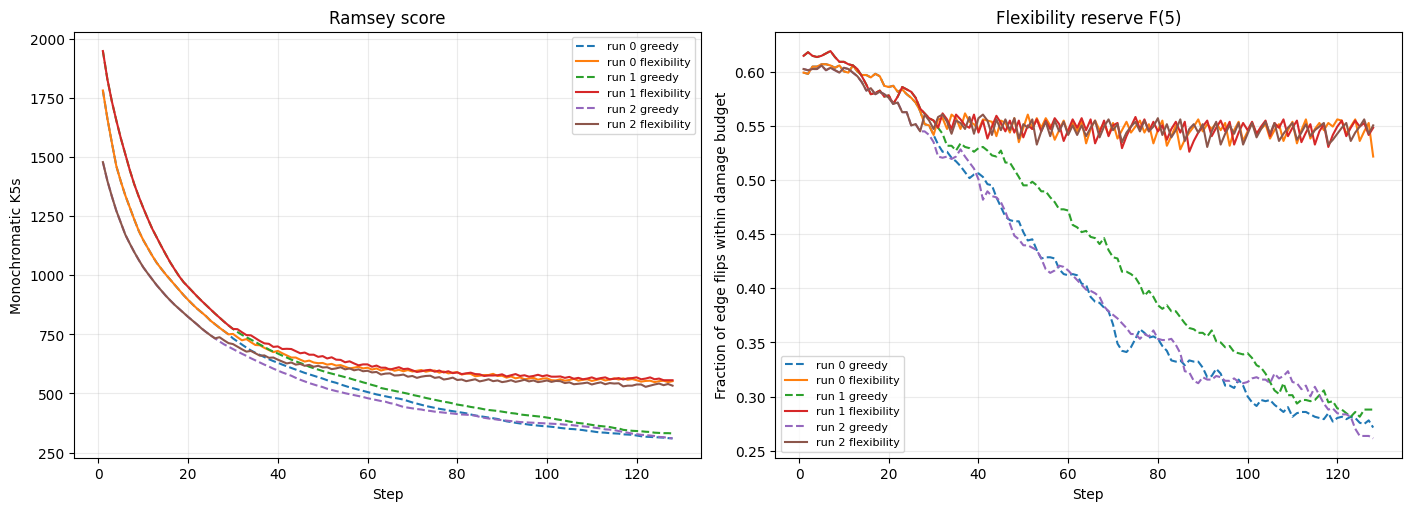

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for result in results:
    trajectory = result['trajectory']
    label = f'run {result["run"]} {result["mode"]}'
    style = '-' if result['mode'] == 'flexibility' else '--'
    axes[0].plot(trajectory['step'], trajectory['score'], style, label=label)
    axes[1].plot(trajectory['step'], trajectory['F5'], style, label=label)

axes[0].set_title('Ramsey score')
axes[0].set_ylabel('Monochromatic K5s')
axes[1].set_title('Flexibility reserve F(5)')
axes[1].set_ylabel('Fraction of edge flips within damage budget')

for ax in axes:
    ax.set_xlabel('Step')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.show()


In [6]:
print('FLEXIBILITY POLICY BASELINE REPORT')
print('=' * 90)
print(
    f'F({MONITOR_BUDGET}) floor={FLEXIBILITY_FLOOR:.1%}, '
    f'maximum temporary damage={MAXIMUM_TEMPORARY_DAMAGE}'
)
print()

for run_number in range(NUMBER_OF_RUNS):
    pair = [result for result in results if result['run'] == run_number]
    print(f'Run {run_number}:')
    for result in pair:
        print(
            f'  {result["mode"]:11s} | '
            f'initial={result["initial_score"]:4d} | '
            f'final={result["final_score"]:4d} | '
            f'best={result["best_score"]:4d} | '
            f'F0={result["final_F0"]:7.3%} | '
            f'F5={result["final_F5"]:7.3%} | '
            f'reorg={result["reorganization_steps"]:3d} | '
            f'time={result["elapsed"]:7.2f}s'
        )
    print()

for mode in ('greedy', 'flexibility'):
    group = [result for result in results if result['mode'] == mode]
    print(
        f'{mode:11s} mean | '
        f'best={np.mean([r["best_score"] for r in group]):.2f} | '
        f'F0={np.mean([r["final_F0"] for r in group]):.3%} | '
        f'F5={np.mean([r["final_F5"] for r in group]):.3%} | '
        f'time={np.mean([r["elapsed"] for r in group]):.2f}s'
    )


FLEXIBILITY POLICY BASELINE REPORT
F(5) floor=55.0%, maximum temporary damage=5

Run 0:
  greedy      | initial=1917 | final= 310 | best= 310 | F0= 1.993% | F5=26.357% | reorg=  0 | time=   0.45s
  flexibility | initial=1917 | final= 552 | best= 548 | F0=15.725% | F5=53.267% | reorg= 55 | time=  96.96s

Run 1:
  greedy      | initial=2113 | final= 331 | best= 331 | F0= 1.550% | F5=29.125% | reorg=  0 | time=   0.35s
  flexibility | initial=2113 | final= 556 | best= 556 | F0=14.839% | F5=55.260% | reorg= 56 | time=  97.67s

Run 2:
  greedy      | initial=1592 | final= 310 | best= 310 | F0= 2.658% | F5=25.692% | reorg=  0 | time=   0.34s
  flexibility | initial=1592 | final= 533 | best= 528 | F0=12.846% | F5=52.935% | reorg= 59 | time= 109.23s

greedy      mean | best=317.00 | F0=2.067% | F5=27.058% | time=0.38s
flexibility mean | best=544.00 | F0=14.470% | F5=53.821% | time=101.29s
